In [9]:
import pandas as pd

df = pd.read_csv("/kaggle/input/health-care/healthcare_dataset.csv")   # change path

# convert dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'], errors='coerce')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'], errors='coerce')


TASK-1:EDA

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


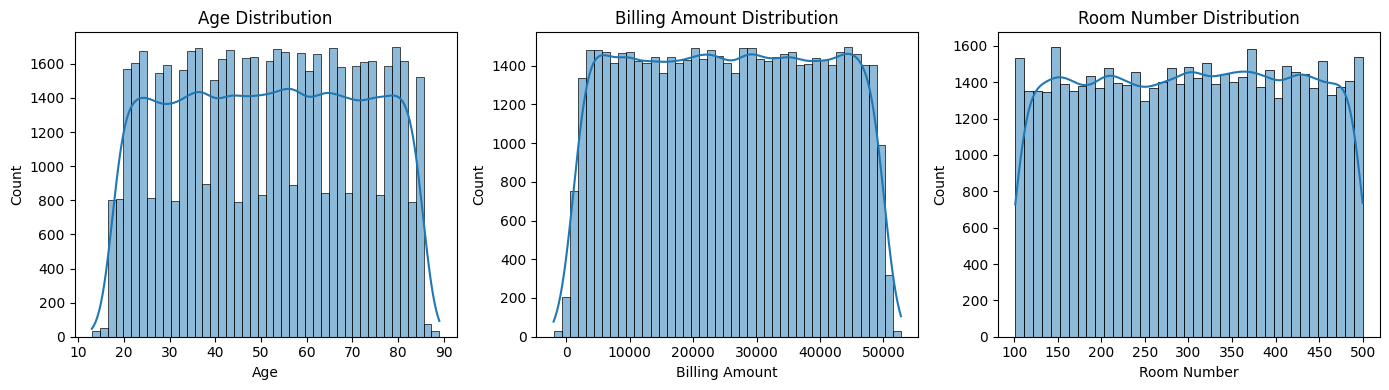

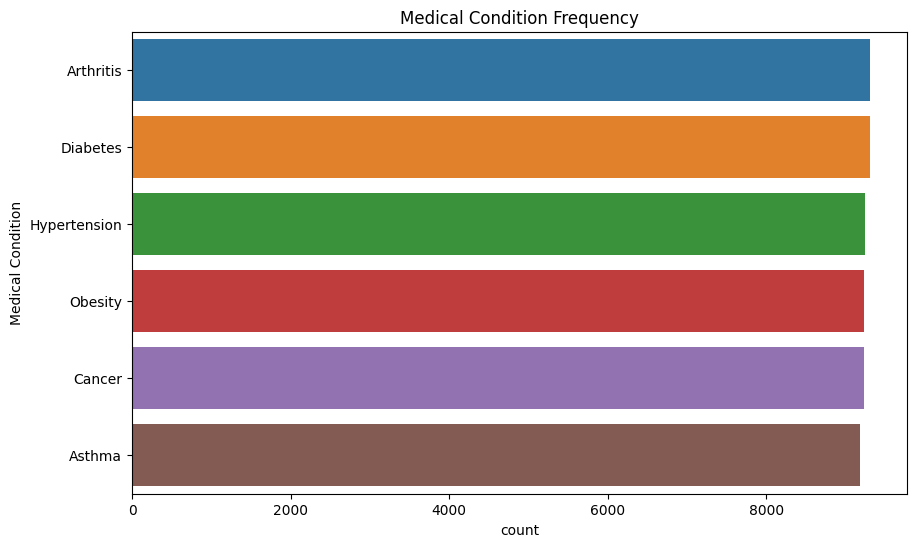

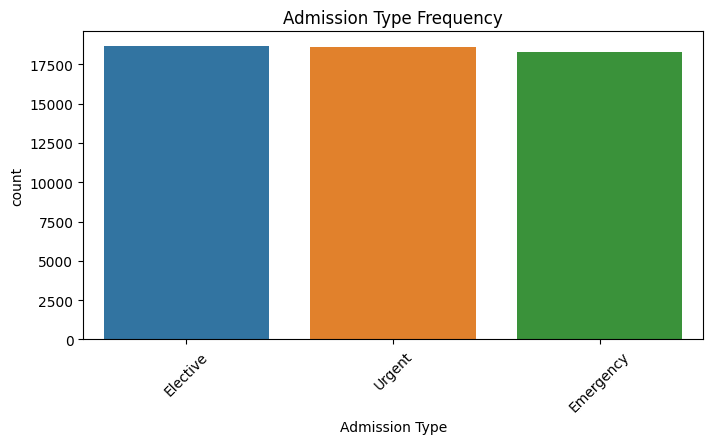

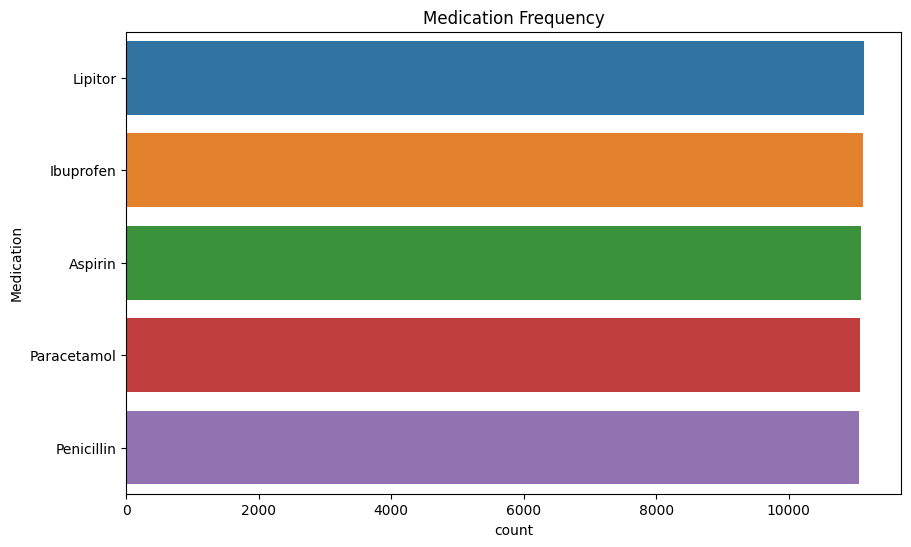

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1 — Distributions
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.histplot(df['Age'], kde=True); plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(df['Billing Amount'], kde=True); plt.title("Billing Amount Distribution")

plt.subplot(1,3,3)
sns.histplot(df['Room Number'], kde=True); plt.title("Room Number Distribution")

plt.tight_layout()
plt.show()

# 2 — Categorical Frequencies
plt.figure(figsize=(10,6))
sns.countplot(y=df['Medical Condition'], order=df['Medical Condition'].value_counts().index)
plt.title("Medical Condition Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.countplot(x=df['Admission Type'], order=df['Admission Type'].value_counts().index)
plt.title("Admission Type Frequency")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(y=df['Medication'], order=df['Medication'].value_counts().index)
plt.title("Medication Frequency")
plt.show()


TASK-2:SUPERVISED LEARNING

Accuracy: 0.44054054054054054

Classification Report:
               precision    recall  f1-score   support

    Abnormal       0.44      0.47      0.46      3754
Inconclusive       0.44      0.43      0.43      3617
      Normal       0.45      0.42      0.43      3729

    accuracy                           0.44     11100
   macro avg       0.44      0.44      0.44     11100
weighted avg       0.44      0.44      0.44     11100



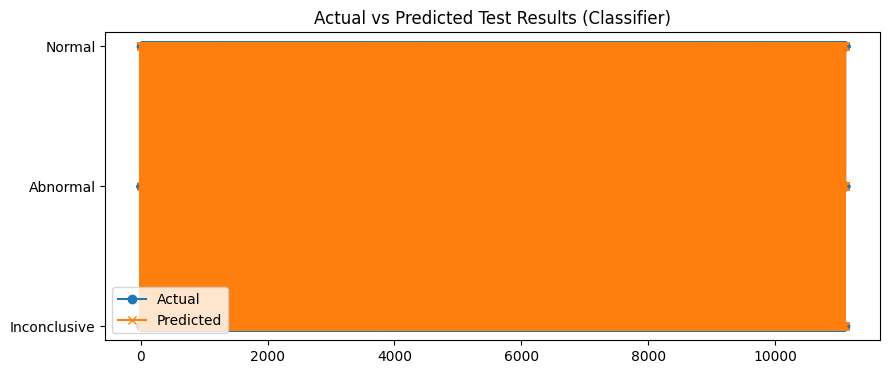

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df_encoded = df.copy()

# Encode categorical columns
cat_cols = ['Name','Gender','Blood Type','Medical Condition','Doctor','Hospital',
            'Insurance Provider','Admission Type','Medication']

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

# Encode TARGET column (Test Results)
target_encoder = LabelEncoder()
df_encoded['Test Results Encoded'] = target_encoder.fit_transform(df_encoded['Test Results'].astype(str))

# Create LOS_days
df_encoded['LOS_days'] = (df_encoded['Discharge Date'] - df_encoded['Date of Admission']).dt.days
df_encoded['LOS_days'] = df_encoded['LOS_days'].fillna(df_encoded['LOS_days'].median())

# Drop datetime and old target column
X = df_encoded.drop(columns=['Test Results','Test Results Encoded','Date of Admission','Discharge Date'])
y = df_encoded['Test Results Encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Classifier model
model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

# Metrics
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred, target_names=target_encoder.classes_))

# Predicted vs actual (text labels)
actual_lbl = target_encoder.inverse_transform(y_test)
pred_lbl = target_encoder.inverse_transform(pred)

plt.figure(figsize=(10,4))
plt.plot(actual_lbl, label="Actual", marker='o')
plt.plot(pred_lbl, label="Predicted", marker='x')
plt.title("Actual vs Predicted Test Results (Classifier)")
plt.legend()
plt.show()


TASK-3:UNSUPERVISED LEARNING

In [14]:
import numpy as np

Q1 = df['Billing Amount'].quantile(0.25)
Q3 = df['Billing Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['Billing_Anomaly'] = df['Billing Amount'].apply(
    lambda x: "Anomaly" if (x < lower or x > upper) else "Normal"
)

anomalies = df[df['Billing_Anomaly']=="Anomaly"]

print("Total anomalies:", len(anomalies))
display(anomalies[['Name','Billing Amount','Medical Condition','Admission Type','Room Number']])

print("\nInterpretation:")
print("• Very high billing = rare expensive cases")
print("• Very low billing = minor treatment or potential data gaps")


Total anomalies: 0


,Name,Billing Amount,Medical Condition,Admission Type,Room Number



Interpretation:
• Very high billing = rare expensive cases
• Very low billing = minor treatment or potential data gaps


TASK-4: AI DOCTOR RECOMMENDATION

In [17]:
def doctor_recommendation_adaptive(age, condition, medication, predicted_result):
    if predicted_result > 180:
        severity = "Critical"
        advice = """
• Immediate medical evaluation recommended.
• Medication adjustment likely needed.
• Avoid all physical exertion.
• Monitor for red-alert symptoms.
"""
    elif predicted_result > 140:
        severity = "High Risk"
        advice = """
• Increase monitoring frequency.
• Consider dose change under doctor supervision.
• Avoid stress, salt, and heavy activity.
• Follow-up required within 48 hours.
"""
    elif predicted_result > 100:
        severity = "Moderate"
        advice = """
• Continue medication.
• Maintain hydration and light exercise.
• Monitor weekly for changes.
"""
    else:
        severity = "Normal"
        advice = """
• Condition stable.
• Continue routine medication.
• Maintain healthy lifestyle.
"""

    return f"""
===============================
AI Doctor Recommendation
===============================
Age: {age}
Condition: {condition}
Medication: {medication}
Predicted Test Result: {predicted_result} → {severity}

Recommendations:
{advice}
"""
patients = [
    {"age": 45, "condition": "Hypertension", "medication": "Amlodipine", "predicted": 138},
    {"age": 62, "condition": "Diabetes", "medication": "Metformin", "predicted": 182},
    {"age": 29, "condition": "Asthma", "medication": "Salbutamol", "predicted": 95}
]

for p in patients:
    print(doctor_recommendation_adaptive(
        age=p["age"],
        condition=p["condition"],
        medication=p["medication"],
        predicted_result=p["predicted"]
    ))



AI Doctor Recommendation
Age: 45
Condition: Hypertension
Medication: Amlodipine
Predicted Test Result: 138 → Moderate

Recommendations:

• Continue medication.
• Maintain hydration and light exercise.
• Monitor weekly for changes.



AI Doctor Recommendation
Age: 62
Condition: Diabetes
Medication: Metformin
Predicted Test Result: 182 → Critical

Recommendations:

• Immediate medical evaluation recommended.
• Medication adjustment likely needed.
• Avoid all physical exertion.
• Monitor for red-alert symptoms.



AI Doctor Recommendation
Age: 29
Condition: Asthma
Medication: Salbutamol
Predicted Test Result: 95 → Normal

Recommendations:

• Condition stable.
• Continue routine medication.
• Maintain healthy lifestyle.


